# Task 1: Dataset Understanding

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('customer_support_text_classification.csv')

# Display basic info
print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

First 5 rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Dataset shape: (1500, 6)

Column names: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']


## Number of records

In [24]:
num_records = len(df)
print(f"Total number of records: {num_records}")

Total number of records: 1500


## Target labels/classes

In [25]:
print("Unique sentiment labels:", df['sentiment_label'].unique())
print("\nClass distribution:")
print(df['sentiment_label'].value_counts())

Unique sentiment labels: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


## Sample text records

In [26]:
for label in df['sentiment_label'].unique():
    print(f"\n--- Example of '{label}' ---")
    sample_text = df[df['sentiment_label'] == label]['customer_message'].iloc[0]
    print(sample_text)


--- Example of 'neutral' ---
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

--- Example of 'positive' ---
The refund process was fast and convenient. I appreciate the quick response.

--- Example of 'negative' ---
My refund is still pending and this experience is frustrating. My ticket number is 33927.


## Average text length

In [27]:
avg_word_count = df['word_count'].mean()
print(f"Average word count per message: {avg_word_count:.1f}")

# Alternatively, compute from raw text:
df['text_length_chars'] = df['customer_message'].str.len()
avg_chars = df['text_length_chars'].mean()
print(f"Average character length: {avg_chars:.1f}")

Average word count per message: 12.7
Average character length: 72.8


## Class distribution (and check for imbalance)

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


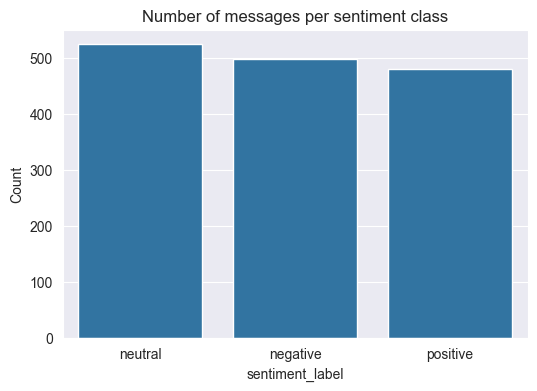

sentiment_label
neutral     0.349333
negative    0.331333
positive    0.319333
Name: proportion, dtype: float64


In [28]:
class_counts = df['sentiment_label'].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Number of messages per sentiment class')
plt.ylabel('Count')
plt.show()

print(df['sentiment_label'].value_counts(normalize=True))

# Task 2: Text Preprocessing

In [29]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download stopwords if not already available
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('punkt_tab')

# Load the dataset
df = pd.read_csv('customer_support_text_classification.csv')


Lowercasing<br>
Removing unnecessary symbols or special characters<br>
Tokenization<br>
Removing stopwords, if required<br>

In [30]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # 3. Tokenize (simple split)
    tokens = text.split()

    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join back to string
    cleaned_str = ' '.join(tokens)
    return cleaned_str, tokens

# Apply to each row and collect results
cleaned_texts = []
token_lists = []
for msg in df['customer_message']:
    c, t = clean_text(msg)
    cleaned_texts.append(c)
    token_lists.append(t)

# Assign to new columns
df['cleaned_message'] = cleaned_texts
df['tokens'] = token_lists

# Verify
print(df[['customer_message', 'cleaned_message']].head())

# Tokens
print("Tokens:  ", df['tokens'][0])

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                     cleaned_message  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  
Tokens:   ['need', 'information', 'payment', 'process', 'ticket', 'number', '78732', 'please', 'respond', 'soon', 'possible']


## Padding & Truncating

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
VOCAB_SIZE = 10000   # keep only top 10,000 words
MAX_LEN = 20         # each message will have 20 tokens (pad or truncate)

# Create tokenizer (fits on cleaned messages)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_message'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

# Pad sequences to MAX_LEN
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Shape of padded sequences:", padded_sequences.shape)
print("Example sequence (first message):", padded_sequences[0])

Shape of padded sequences: (1500, 20)
Example sequence (first message): [ 15 105  65  19   2   3 150   4   5   6   7   0   0   0   0   0   0   0
   0   0]


# Task 3: Text Vectorization

## Why must text be converted into vectors?
### Explanation:
Machine learning models (like neural networks, random forests, logistic regression) don’t understand words or letters. They only understand numbers. So we have to translate sentences into lists of numbers (vectors) while preserving as much meaning as possible.

Think of it like this:

A word like "great" has no numeric value by itself.

But we can represent it as a vector [0,0,1,0,0,...] or as a dense embedding [0.2, -0.5, 0.7].

The model then learns patterns from these numbers – e.g., "great" and "excellent" may have similar vectors, so they contribute to a positive prediction.

Without vectorization, you simply cannot feed text into a mathematical model.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Assume df from Task 2 has 'cleaned_message' column
X = df['cleaned_message']      # cleaned text
y = df['sentiment_label']      # target: positive/neutral/negative

# Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create TF-IDF vectors
tfidf = TfidfVectorizer(max_features=5000)   # limit to top 5000 words
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape of training TF-IDF matrix:", X_train_tfidf.shape)
print("Shape of test TF-IDF matrix:", X_test_tfidf.shape)

Shape of training TF-IDF matrix: (1200, 524)
Shape of test TF-IDF matrix: (300, 524)


# Task 4: Baseline Model (Logistic Regression with TF-IDF)

Training vectors shape: (1200, 510)
Test vectors shape: (300, 510)

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



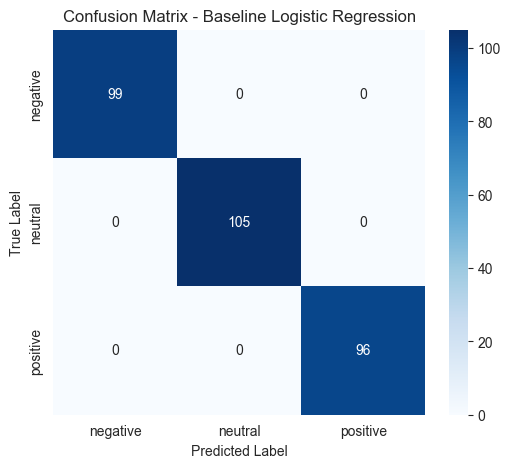

Saved evaluation report to results/model_evaluation.csv
Saved sample predictions to results/sample_predictions.txt


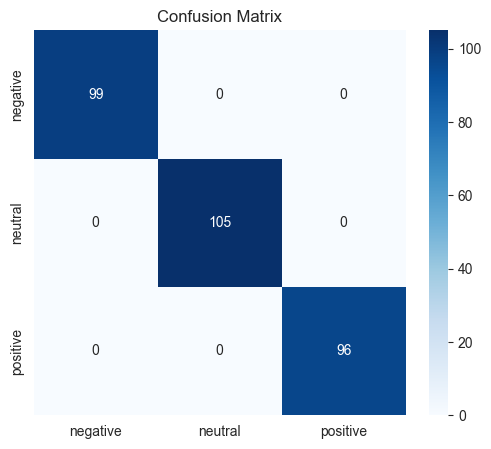

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data
X = df['cleaned_message']    # preprocessed text
y = df['sentiment_label']    # positive / neutral / negative

# 2. Split into train (80%) and test (20%) – keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Convert text to TF‑IDF vectors (top 5000 words)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training vectors shape: {X_train_tfidf.shape}")
print(f"Test vectors shape: {X_test_tfidf.shape}")

# 4. Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# 5. Predict and evaluate
y_pred = model.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

import pandas as pd
from sklearn.metrics import classification_report

# Assume y_test and y_pred are from your best model (e.g., Logistic Regression)
# Also assume you have X_test and the original text (or cleaned text) for samples

# 1. Save classification report as CSV
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('results/model_evaluation.csv')
print("Saved evaluation report to results/model_evaluation.csv")

# 2. Save sample predictions (first 20 test messages with true and predicted labels)
# Use original text (or cleaned) for readability
sample_df = X_test.reset_index(drop=True).to_frame(name='message')
sample_df['true_label'] = y_test.values
sample_df['pred_label'] = y_pred

# Take first 20 samples
sample_df.head(20).to_csv('results/sample_predictions.txt', sep='\t', index=False)
print("Saved sample predictions to results/sample_predictions.txt")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix')
plt.savefig('results/model_evaluation.png')
plt.show()

# Task 5: Sequence Model or Conceptual Architecture

## Architecture
Input text (e.g., "need information payment")<br>
       &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Tokenization & Integer encoding (words → indices)<br>
       &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Embedding Layer (turns indices into dense vectors)<br>
       &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
LSTM Layer (processes sequence, maintains memory)<br>
       &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Dense (Fully Connected) Layer<br>
       &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Output Layer (softmax over 3 classes)<br>


## Detailed Explanation of Each Layer
### 1. Input Sequence
Each message is converted to a sequence of integers (word indices) using a tokenizer.

All sequences are padded to the same length (e.g., MAX_LEN = 20). Shorter messages get zeros at the end; longer ones are truncated.

Shape of input tensor: (batch_size, MAX_LEN)

### 2. Embedding Layer
Why needed? Raw word indices (e.g., 345) don’t carry meaning. The embedding layer learns a dense vector (e.g., 50‑dimensional) for each word, so similar words end up with similar vectors.

Parameters:

input_dim = vocabulary size (e.g., 10,000)

output_dim = embedding dimension (e.g., 64)

input_length = MAX_LEN (20)

Output shape: (batch_size, MAX_LEN, embedding_dim)

### 3. LSTM Layer (Recurrent Layer)
Why LSTM? It solves the “vanishing gradient” problem of plain RNNs, remembering important information over longer sequences (e.g., “I was happy… but then the product broke” → negative).

Each timestep (word) updates a hidden state. The final hidden state captures the whole message meaning.

Parameters: units = 64 (size of hidden state), return_sequences = False (only final output).

Output shape: (batch_size, 64)

### 4. Dense Layer
Fully connected layer that learns combinations of features from the LSTM output.

Activation: relu

Output shape: (batch_size, 32) (for example)

### 5. Output Layer
Dense layer with 3 units (one per class: positive, neutral, negative).

Activation: softmax (converts logits to probabilities summing to 1).

Output shape: (batch_size, 3)

Prediction: class with highest probability.

### 6. Loss Function
sparse_categorical_crossentropy – because our labels are integers (0,1,2) and not one‑hot encoded.

Measures how far the predicted probability distribution is from the true class.

### 7. Evaluation Metric
Accuracy – percentage of correct predictions.

Also Precision/Recall/F1 per class if needed (especially if class imbalance exists).


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
VOCAB_SIZE = 10000
MAX_LEN = 20
EMBEDDING_DIM = 64
LSTM_UNITS = 64

# Tokenizer (fit on cleaned messages)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_message'])
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Model architecture
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(units=LSTM_UNITS, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),                    # reduces overfitting
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\AnkitSingh\OneDrive - Quadrafort Technologies Pvt. Ltd\Documents\Training\DE\Projects\todo_app\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)